<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

Accompanying Worksheets to Class Notes, also printed in [Introduction to Computational Physics](https://www.amazon.com/Introduction-Computational-Physics-Differential-Simulations/dp/B0GJD4DNNY).

#  Worksheet 22: Monte Carlo

- Use Monte Carlo to estimate $\pi$ with uncertainty;
- Implement the MC Simple Sampling Algorithm;
- MC integration with error bars; compare to Simpson for a test integral;
- Create a Markov chain.

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

## Monte Carlo Method

The most efficient way to integrate high-dimensional integrals is often by Monte Carlo method. For illustration, we will solve one-dimensional integrals first. You can approximate an integral as follows using *simple sampling*, which means that we randomly choose numbers $x_i$ from a uniform distribution `random.uniform(a,b)` with $p(x) = 1/(b-a)$:  

$$
\int_a^b f(x) dx \approx \frac{(b-a)}{N} \left[  \sum_{i=1}^N f(x_i) \right]
$$

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">


## Task 1: Monte Carlo with Simple Sampling

Compute the following integral using Monte Carlo approach: 

$$
A = \int_0^{10} 5 \cos^2 (x) \; dx
$$

Create $N = 100$ random numbers and compare your answer with the quadrature method `quad`.

</div>

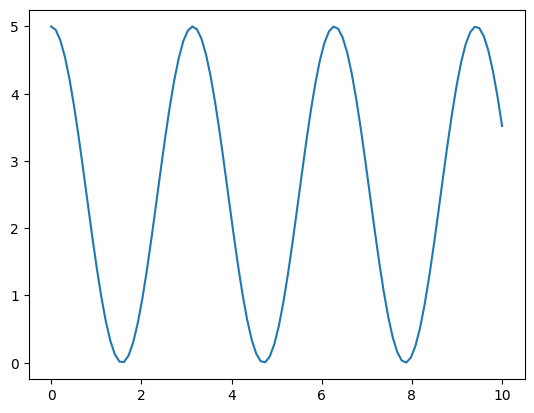

In [106]:
def f(x): return 5*np.cos(x)**2
x_vec = np.linspace(0, 10, 100)
fig, ax = plt.subplots()
ax.plot(x_vec, f(x_vec), label="f(x)")
plt.show()

In [107]:
# Random Number
rng = np.random.default_rng(71)


## Markov Chains

Markov chains are widely used in the sciences due to a rigorous mathematical underpinning that provides stable properties and guarantees convergence provided certain conditions are met. They contain probabilities of transitions between states. Think of a graph with multiple nodes (*vertices*) and edges that connect the nodes.   There is a transition probability of a process going from one node to the next along one edge.

A clear example is radioactive decay.  In a Markov chain, the current state depends only on the immediate previous state. Even if that state arose from different parent isotopes, the resulting isotope will decay in the same way, regardless of its origin. This behavior resembles a system with short-term memory.




The Metropolis algorithm is a fundamental and specific MCMC method. It generates a Markov chain by iteratively proposing new states and accepting or rejecting them based on a transition probability. The acceptance probability ensures that the chain converges to the desired distribution.  

As mentioned for the expectation value $\mathbb{E}[M]$ it would be convenient to have the normalized probability function for $e^{-H/k_BT}$. The Metropolis algorithm generates a distribution of values $x_0, \ldots x_n, x_{n+1}, \ldots$ that has the shape of any chosen function without a normalization factor.

Imagine, you were to generate a particular *Weibull distribution* that has the shape

$$
q(x) \sim \left( \frac{x}{\lambda} \right)^{\gamma-1} e^{-\left(\frac{x}{\lambda}\right)^\gamma}
$$  

for positive values of $\lambda$ and $\gamma$. Although it is possible to calculate the normalization factor in this case ($\gamma/\lambda$), for more complex distributions it may not be as convenient.

The basic method that Metropolis uses implicitly assumes a *detailed balance* or mathematically $q(x|\tilde{x})=q(\tilde{x}|x)$. It starts with a known distribution, a *nominal distribution*, such as a uniform or normal distribution $p(x)$ with the goal to generate a sequence of numbers that has a posterior distribution $q(x)$. The probability to go from state $y$ to state $x$ is denoted with $q(x|y)$; for the moment, we assume some symmetry in the distribution (detailed balance).

 
### Metropolis Algorithm 

(Note: iff $q(x|\tilde{x})=q(\tilde{x}|x)$)

Given proposal distribution $q(x)$ and target distribution $\pi(x)$

1.  initialize: $x_0$
2.  proposal: new candidate $\tilde{x}$ from $q(\tilde{x}|x)$
3.  probability: $\alpha = \min(1, \pi(\tilde{x})/\pi(x))$
4.  acceptance / rejection: generate random number $r \in [0,1]$ and accept if $r \leq \alpha$.
5.  iterate: repeat to generate more values in Markov chain
 

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">



## Task 2: Markov Chain

Create a Markov chain with 1 million samples for the following function $f(x) = \frac{1}{e^\frac{E-\mu}{kT} + 1}$.

First define the following two functions:

* `normal_proposal(x, sigma=2)` - Gaussian distribution
* `target_distribution(x, mu=1, T=0.5)` - $f(x, \mu, T) = \frac{1}{e^\frac{x-\mu}{kT} + 1}$, $T$ is a constant, $x$ (energy) varies.

1.  initialize: $x_0$ (**NOTE:** use $x_0 = 1$ or something like that)
2.  proposal: new candidate $\tilde{x}$ from $q(\tilde{x}|x)$ (**NOTE:**  $\tilde{x}$ is a random number from the proposal function at last number $x_n$)
3.  if $\tilde{x} <0$, then immediately reject and add $x_n$ to the chain, our distribution is positive, skip to step 6
4.  calculate acceptance ratio ($\alpha=$ target_distribution($\tilde{x}$) / target_distribution($x_n$))
5.  generate random number $r \in [0,1]$ and add (accept) $\tilde{x}$, if $\alpha > r$, otherwise add $x_n$ (so reject $\tilde{x}$)
6.  iterate: go to step 2

In [108]:
def normal_proposal(x, sigma=2):
    return np.random.normal(x, sigma)
  
# your target distribution

In [109]:
# Markov Chain Monte Carlo
x0 = 1 # start with mu
x = [x0]
N = 100000

for i in range(N):
    # add algorithm here
    ...

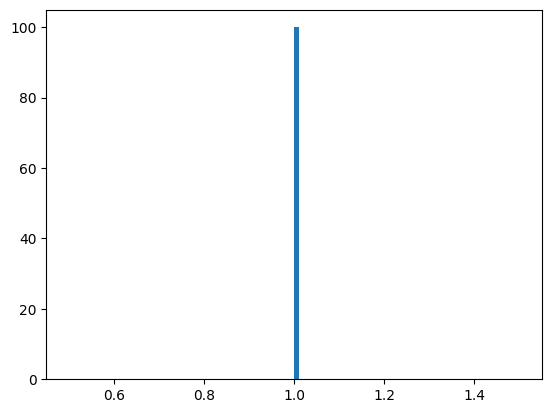

In [110]:
# your graph
fig, ax = plt.subplots()
ax.hist(x, bins=100, density=True, label="MCMC samples")
plt.show()

# Worksheet 24: Units and Uncertainty

- Represent measured quantities with physical units;
- Access fundamental constants with values and units;
- Model experimental uncertainty and propagate errors;
- Validate uncertainty progation via multiple approaches.

## Units and Error Analysis  

Computational physics often relies on dimensionless, floating-point calculations, but real measurements come with physical units and unavoidable uncertainty that must be carried through any analysis. Errors are easily introduced from unit conversions.  In this chapter, you will use `pint`, `uncertainties`, and `scipy.constants` to attach units and error bars to quantities, propagate uncertainties through calculations, and interpret results using reliable physical constants.

In [111]:
# Uncomment the following lines to install the required packages if you haven't already
# !pip3 install pint
# !pip3 install uncertainties

In [112]:
import scipy.constants as const
from uncertainties import ufloat
import uncertainties.umath as um
import pint
u = pint.UnitRegistry(system='mks') 

These fundamental constants are available in the `scipy.constants` library, which we renamed as `const`. The gravitational constant would be `const.G` or `const.e` for the electron's charge value. 

| Name | Constant | Value | Units |
|------------------|------------------|------------------|------------------|
| Gravitational constant | G | $6.67430(15) \cdot 10^{-11}$ | m^3^/kg/s |
| Bohr magneton | $\mu_B$ | $9.2740100783(28) \cdot 10^{-24}$ | J/T |
| proton rms charge radius | $r_p$ | $8.414(19) \cdot 10^{-16}$ | m |
| electron charge | q | $1.602176634 \cdot 10^{-19}$ | C |

Some constants require the full name. These names are best found with `find()`: as in `const.find("Bohr")` or `const.find("proton")` for example. From the results, we   retrieve the values using the full key. 

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

## Task 3: Find Constants

Find the following values of constants:

* speed of light
* mass of neutron
* Boltzmann constant
* $\mu_0$ from Biot-Savar Law
* Bohr magneton

For unit-aware constants, run `const.physical_constants`, which returns the value, units and uncertainty of the constant.

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

## Task 4: Find Bohr Magneton with Units

Find Bohr Magneton with Units and also speed of light with units. What are the uncertainties?

In [113]:
# your code

In contrast, in `pint`, when you retrieve the gravitational constant, `u.gravitational_constant` it provides you with a `Unit` object. So, in order to see the number, you would convert it to a `Quantity` object, which contains both values and units.

## Units  

Given the limited *precision* of computational methods, we should carefully choose physical *scales* and *units* appropriate to the system. This means that physical equations are often converted to contain only dimensionless variables. In general, we transform our variables that have units into *dimensionless* variables, then perform the computation. Frequently, the interpretation of the results requires us to add the units back.

If the speed is 100 km/h, we can say `v=100 * u.km / u.hour`. The generated objects are of type `Quantity`, which has the transformative method `.to()`.

For unit-aware constants, run `const.physical_constants`, which returns the value, units and uncertainty of the constant.

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

## Task 5: Unit Conversion

Convert the following:

- 100 km/h into m/s
- 64 oz. into g
- 2 m / 20 years into nm/s

In [114]:
# your code

### UFloat Method

Imagine you measure the voltage and current across a resistor and want to obtain the resistance. In the first measurement you obtain a voltage of 5.01 V with an uncertainty of 10 mV. When you measure the current, you find 5.12mA +/- 0.02mA. We now compute the resistance, which for a linear device is given by Ohm's relation: $R = V/I$. \index{ufloat}

```{python}
V = ufloat(5.01, 0.01) * u.volt
I = (ufloat(5.12, 0.02) * u.mA).to_base_units()
R = V/I  # ohmic relation
print(R.to(u.ohm))
```

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

## Task 6: Error Propagation

Use the Coulomb's Law for two charges of $1.5 \pm 0.1$ nC that are separated by $6.0 \pm 0.2$ cm and find the force with its uncertainty.

$$
F = \frac{1}{4\pi \varepsilon_0} \frac{Q^2}{r^2}
$$

Use the `const.find()` to find the constant $\varepsilon_0$. 

In [115]:
# your code

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

## Task 7: Muon Momentum

Find the momentum of a typical *muon*. Muons move at an average speed of $0.994 \pm 0.002 c$, where $c$ is the speed of light. Use $p = \gamma m v$ to find the momentum. The muon's mass is found with `const.physical_constants['muon mass']`,  $\gamma$ is the relativistic factor.

In [116]:
const.physical_constants['muon mass']

(1.883531627e-28, 'kg', 4.2e-36)

In [117]:
# Your code

The End.